[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Chapters/chapter_11/chapter_11_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 11 — Survival Analysis
## Lab: Kaplan–Meier, log-rank, Cox model with lifelines

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal.** Establish the censoring convention in `BrainCancer`; show why the naive analyses fail; estimate a Kaplan–Meier curve with a confidence band; run a log-rank test; fit, read and check a Cox proportional-hazards model. Requires `pip install lifelines`.

Every number the lecture slides quote for this chapter is reproduced below from the same data with the same methods, so the deck and this notebook can be checked against each other line by line.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP'), ('lifelines', 'lifelines')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. Data and the censoring convention

`BrainCancer` holds 88 patients treated with stereotactic radiation, followed for up to 82.56 months. Before anything else we must settle what `status` means: `lifelines` expects **1 = the event happened**, and getting this backwards silently inverts every curve in the chapter.

In [2]:
BC = load('BrainCancer', index_col=0)   # the CSV carries an unnamed row-number column
print(BC.shape)
print(BC['status'].value_counts().to_dict())   # how many of each code?
print('missing values:', BC.isna().sum().sum(), '(one diagnosis)')
BC.head()

(88, 8)
{0: 53, 1: 35}
missing values: 1 (one diagnosis)


,sex,diagnosis,loc,ki,gtv,stereo,status,time
1,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
2,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
3,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
4,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
5,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


In [3]:
# Which polarity is right? Decide it from the data, not from memory.
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

male = BC['sex'] == 'Male'
for label, event in [('status = 1 is the EVENT', BC['status']),
                     ('status = 0 is the EVENT', 1 - BC['status'])]:
    km = KaplanMeierFitter().fit(BC['time'], event)
    r = logrank_test(BC.loc[male, 'time'], BC.loc[~male, 'time'],
                     event[male], event[~male])          # ISLP publishes chi2 = 1.44
    print('%-24s events=%3d  median=%7.2f  sex log-rank chi2=%.4f'
          % (label, int(event.sum()), km.median_survival_time_, r.test_statistic))

status = 1 is the EVENT  events= 35  median=  47.80  sex log-rank chi2=1.4405
status = 0 is the EVENT  events= 53  median=  39.25  sex log-rank chi2=0.9040


**Reading the output.** With `status = 1` read as **death** there are 35 deaths and 53 censored observations (60.2% censored), the median survival is 47.8 months and the sex log-rank statistic is 1.4405 — exactly the value published in ISLP. The reversed coding gives 53 "events" and a log-rank statistic that matches nothing. **Convention established for the whole notebook: `status = 1` is the event (death), `status = 0` is right-censored.**

## 2. Why the naive analyses fail

Three shortcuts suggest themselves, and all three are wrong. The deck quotes the medians 11.6, 23.7 and 47.8 months; they come from here.

In [4]:
import numpy as np

t, d, n = BC['time'].values, BC['status'].values, len(BC)

km        = KaplanMeierFitter().fit(t, d)                                 # honest estimate
km_drop   = KaplanMeierFitter().fit(t[d == 1], np.ones((d == 1).sum()))   # (a) drop censored
km_asdead = KaplanMeierFitter().fit(t, np.ones(n))                        # (b) all are events
naive_S24 = 1 - ((t <= 24) & (d == 1)).sum() / n                          # (c) never die

print('(a) drop the %d censored patients : median %5.2f'
      % ((d == 0).sum(), km_drop.median_survival_time_))
print('(b) treat censoring as death      : median %5.2f' % km_asdead.median_survival_time_)
print('(c) censored patients never die   : S(24) = %.3f, flattens at %.3f'
      % (naive_S24, 1 - d.sum() / n))
print('    Kaplan-Meier                  : median %5.2f, S(24) = %.3f'
      % (km.median_survival_time_, km.survival_function_at_times(24).iloc[0]))

(a) drop the 53 censored patients : median 11.57
(b) treat censoring as death      : median 23.67
(c) censored patients never die   : S(24) = 0.716, flattens at 0.602
    Kaplan-Meier                  : median 47.80, S(24) = 0.683


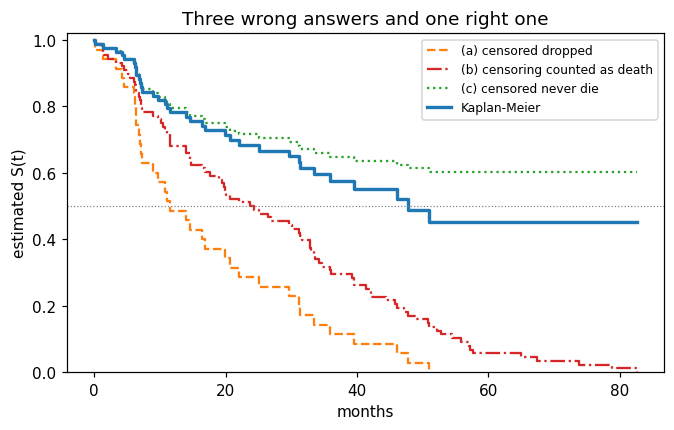

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
km_drop.plot_survival_function(ax=ax, ci_show=False, color='C1', ls='--',
                               label='(a) censored dropped')
km_asdead.plot_survival_function(ax=ax, ci_show=False, color='C3', ls='-.',
                                 label='(b) censoring counted as death')
grid = np.sort(np.unique(np.r_[0.0, t]))                       # (c) as a step function
ax.step(grid, 1 - np.array([((t <= u) & (d == 1)).sum() for u in grid]) / n,
        where='post', color='C2', ls=':', label='(c) censored never die')
km.plot_survival_function(ax=ax, ci_show=False, color='C0', lw=2.2, label='Kaplan-Meier')
ax.axhline(0.5, color='grey', lw=0.8, ls=':')
ax.set(xlabel='months', ylabel='estimated S(t)', ylim=(0, 1.02),
       title='Three wrong answers and one right one')
ax.legend(fontsize=8)
plt.show()

**Reading the output.** Shortcuts (a) and (b) both *understate* survival — (a) keeps only the patients who died inside the study, (b) treats a lower bound as an exact time. Shortcut (c) *overstates* it: pretending the censored never die caps the curve at $1-35/88=0.602$, so the median is never reached. The Kaplan–Meier curve is the only one of the four that uses all 88 patients for exactly what each of them proves.

## 3. Kaplan–Meier

$\hat S(t)=\prod_{k:\,t_k\le t}\left(1-d_k/r_k\right)$, where $d_k$ counts events at the $k$-th distinct event time and $r_k=\#\{i:Y_i\ge t_k\}$ counts those still at risk.

In [6]:
km = KaplanMeierFitter().fit(BC['time'], BC['status'], label='all patients')

print('S(20)  = %.4f' % km.survival_function_at_times(20).iloc[0])
print('95% CI  ', np.round(km.confidence_interval_.loc[:20].iloc[-1].values, 4))
print('median = %.2f' % km.median_survival_time_)
for u in [10, 40, 60]:
    print('S(%2d)  = %.4f' % (u, km.survival_function_at_times(u).iloc[0]))
print('still under observation after month 20:', int((BC['time'] > 20).sum()))

S(20)  = 0.7132
95% CI   [0.5996 0.7998]
median = 47.80
S(10)  = 0.8206
S(40)  = 0.5525
S(60)  = 0.4515
still under observation after month 20: 48


In [7]:
# The first three steps by hand: r_k drops for censoring as well as for deaths.
print(km.event_table.head(7)[['at_risk', 'observed', 'censored']])
print('\nrunning product:',
      np.round([87 / 88, 87 / 88 * 85 / 86, 87 / 88 * 85 / 86 * 82 / 83], 4))

          at_risk  observed  censored
event_at                             
0.00           88         0         0
0.07           88         1         0
1.18           87         0         1
1.41           86         1         0
1.54           85         0         1
2.03           84         0         1
3.38           83         1         0

running product: [0.9886 0.9771 0.9654]


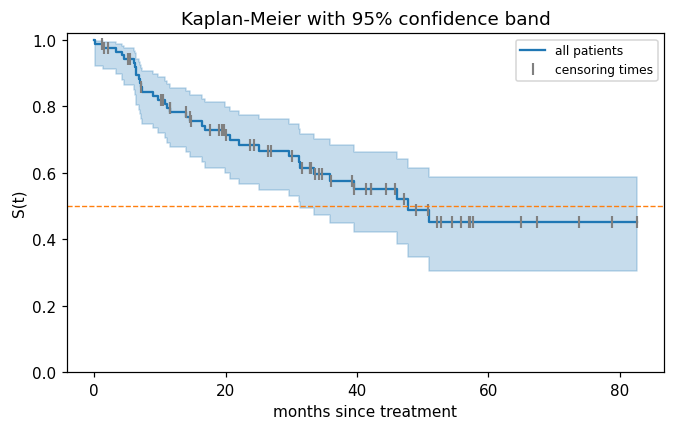

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
km.plot_survival_function(ax=ax, color='C0')                 # the band is drawn by default
cens = BC.loc[BC['status'] == 0, 'time']
ax.plot(cens, km.survival_function_at_times(cens).values, '|', color='grey',
        ms=8, mew=1.4, label='censoring times')
ax.axhline(0.5, color='C1', lw=0.9, ls='--')
ax.set(xlabel='months since treatment', ylabel='S(t)', ylim=(0, 1.02),
       title='Kaplan-Meier with 95% confidence band')
ax.legend(fontsize=8)
plt.show()

Female n=45 deaths=15 median= 51.02  S(30)=0.7469
Male   n=43 deaths=20 median= 31.25  S(30)=0.5533


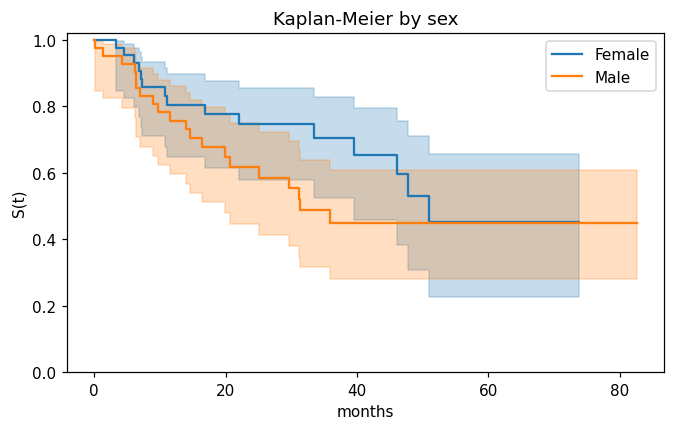

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for sex, colour in [('Female', 'C0'), ('Male', 'C1')]:
    m = BC['sex'] == sex
    k = KaplanMeierFitter().fit(BC.loc[m, 'time'], BC.loc[m, 'status'], label=sex)
    k.plot_survival_function(ax=ax, color=colour)
    print('%-6s n=%2d deaths=%2d median=%6.2f  S(30)=%.4f'
          % (sex, m.sum(), BC.loc[m, 'status'].sum(), k.median_survival_time_,
             k.survival_function_at_times(30).iloc[0]))
ax.set(xlabel='months', ylabel='S(t)', ylim=(0, 1.02), title='Kaplan-Meier by sex')
plt.show()

**Reading the output.** $\hat S(20)=0.7132$ with a 95% interval of $[0.600,0.800]$, and the median is 47.8 months (its lower 95% bound is 31.25 and there is no upper bound — the curve never gets far enough below 0.5). The band widens to the right because only 48 of the 88 patients are still under observation after month 20, and the curve flattens at 0.452 rather than reaching zero because the largest observation is censored. Split by sex, the male median is 31.25 months against 51.02 for women; whether that gap is more than noise is the next section's question.

## 4. Log-rank test

At every death time, compare the deaths observed in group 1 with the number expected if the two groups were identical, then sum: $Z^2=(O_1-E_1)^2/V_1 \sim \chi^2_1$.

In [10]:
res = logrank_test(BC.loc[male, 'time'],   BC.loc[~male, 'time'],
                   BC.loc[male, 'status'], BC.loc[~male, 'status'])
print('log-rank chi2 = %.4f   p = %.4f' % (res.test_statistic, res.p_value))

log-rank chi2 = 1.4405   p = 0.2301


In [11]:
# The same statistic assembled by hand, one 2x2 table per death time.
O = E = V = 0.0
for tk in np.sort(BC.loc[BC['status'] == 1, 'time'].unique()):
    at_risk = BC['time'] >= tk
    r1, r = (at_risk & male).sum(), at_risk.sum()           # at risk: group 1, and total
    dk = ((BC['time'] == tk) & (BC['status'] == 1)).sum()   # deaths at this time
    d1 = ((BC['time'] == tk) & (BC['status'] == 1) & male).sum()
    O += d1
    E += dk * r1 / r                                        # hypergeometric mean ...
    V += dk * (r1 / r) * (1 - r1 / r) * (r - dk) / (r - 1)  # ... and variance
print('O_male = %.0f   E_male = %.4f   V_male = %.4f' % (O, E, V))
print('Z = %.4f      Z^2 = %.4f' % ((O - E) / np.sqrt(V), (O - E) ** 2 / V))

O_male = 20   E_male = 16.4605   V_male = 8.6969
Z = 1.2002      Z^2 = 1.4405


**Reading the output.** Men suffered 20 deaths where the risk sets predicted 16.4605, an excess of 3.54 with standard error $\sqrt{8.6969}=2.949$, so $Z=1.200$ and $\chi^2_1=1.4405$, $p=0.230$. With 88 patients and 35 events there is **no evidence** of a sex difference in survival: a 20-month gap between medians is entirely consistent with chance at this sample size. Note also what the test cannot see — if two curves cross, the early and late excesses cancel in $O_1-E_1$ and the test reports nothing.

## 5. Cox proportional-hazards model

$h(t\mid x)=h_0(t)\exp(x^{\top}\beta)$: the baseline hazard $h_0$ is never estimated, because it cancels out of the partial likelihood. The one missing `diagnosis` leaves 87 complete cases.

In [12]:
from lifelines import CoxPHFitter

BCc = BC.dropna().reset_index(drop=True)                    # 87 complete cases
BCc['diagnosis'] = pd.Categorical(BCc['diagnosis'],         # Meningioma = reference,
        categories=['Meningioma', 'HG glioma', 'LG glioma', 'Other'])  # as in ISLP
X = pd.get_dummies(BCc, drop_first=True).astype(float)      # drop the reference level
print(X.shape)
print(list(X.columns))

(87, 10)
['ki', 'gtv', 'status', 'time', 'sex_Male', 'diagnosis_HG glioma', 'diagnosis_LG glioma', 'diagnosis_Other', 'loc_Supratentorial', 'stereo_SRT']


In [13]:
cph = CoxPHFitter().fit(X, duration_col='time', event_col='status')
cph.summary[['coef', 'exp(coef)', 'se(coef)',
             'exp(coef) lower 95%', 'exp(coef) upper 95%', 'z', 'p']].round(4)

,coef,exp(coef),se(coef),exp(coef) lower 95%,exp(coef) upper 95%,z,p
covariate,,,,,,,
ki,-0.0550,0.9465,0.0183,0.9132,0.9811,-3.0008,0.0027
gtv,0.0343,1.0349,0.0223,0.9906,1.0812,1.5355,0.1247
sex_Male,0.1837,1.2017,0.3604,0.5930,2.4352,0.5099,0.6101
diagnosis_HG glioma,2.1546,8.6241,0.4505,3.5664,20.8547,4.7824,0.0000
diagnosis_LG glioma,0.9150,2.4969,0.6382,0.7148,8.7215,1.4339,0.1516
diagnosis_Other,0.8857,2.4247,0.6579,0.6678,8.8031,1.3463,0.1782
loc_Supratentorial,0.4412,1.5546,0.7037,0.3914,6.1741,0.6270,0.5307
stereo_SRT,0.1778,1.1946,0.6016,0.3674,3.8839,0.2955,0.7676


In [14]:
print('HR per 10 Karnofsky points : %.3f' % np.exp(10 * cph.params_['ki']))
print('HR, HG glioma vs meningioma: %.3f' % np.exp(cph.params_['diagnosis_HG glioma']))
print('concordance index          : %.4f' % cph.concordance_index_)
lr = cph.log_likelihood_ratio_test()
print('likelihood-ratio test      : chi2 = %.2f on %d df, p = %.2g'
      % (lr.test_statistic, lr.degrees_freedom, lr.p_value))

HR per 10 Karnofsky points : 0.577
HR, HG glioma vs meningioma: 8.624
concordance index          : 0.7943
likelihood-ratio test      : chi2 = 41.37 on 8 df, p = 1.8e-06


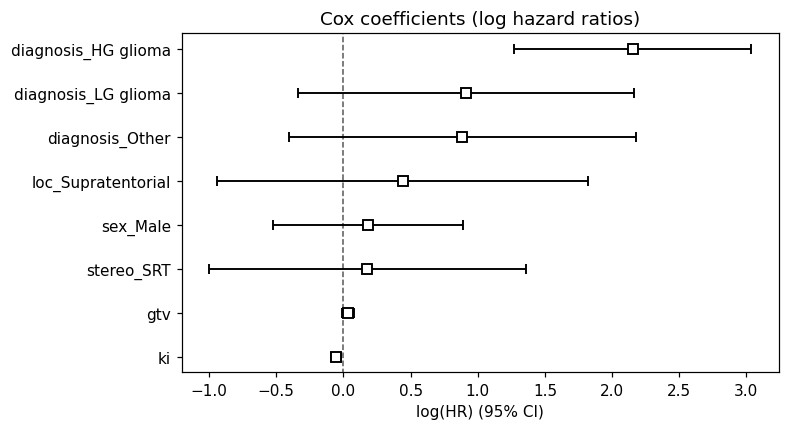

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
cph.plot(ax=ax)                       # log hazard ratios with their 95% intervals
ax.set_title('Cox coefficients (log hazard ratios)')
plt.show()

**Reading the output.** Only two covariates separate from the null. `ki`: $\hat\beta=-0.0550$, so each Karnofsky point multiplies the death rate by $e^{-0.0550}=0.947$ and ten points by $e^{-0.550}=0.577$ — *holding tumour type, volume, site, sex and technique fixed, ten more Karnofsky points are associated with a 42% lower death rate at every follow-up time*. `diagnosis = HG glioma`: $e^{2.1546}=8.62$ times the hazard of a meningioma, 95% interval $[3.57,\,20.85]$. The overall likelihood-ratio test is $\chi^2_8=41.4$, $p=1.8\times10^{-6}$, and the concordance index is 0.794 — good ranking, but read on the training data, so optimistic.

A hazard ratio is **not** a risk ratio: $\widehat{HR}=8.62$ does not mean HG glioma patients are 8.6 times as likely to die by any particular date. Section 6 turns the coefficients into survival probabilities, which is the form a decision needs.

## 6. Checking proportional hazards and predicting curves

Proportional hazards is an *assumption*. Schoenfeld residuals test whether each hazard ratio drifts with time; a small $p$-value is evidence **against** proportionality.

In [16]:
from lifelines.statistics import proportional_hazard_test

ph = proportional_hazard_test(cph, X, time_transform='rank')
print(ph.summary[['test_statistic', 'p']].round(4))
print('\nsmallest p-value: %.4f' % ph.summary['p'].min())

                     test_statistic       p
diagnosis_HG glioma          0.0492  0.8245
diagnosis_LG glioma          0.1148  0.7347
diagnosis_Other              0.5632  0.4530
gtv                          0.4928  0.4827
ki                           0.0518  0.8199
loc_Supratentorial           0.2390  0.6249
sex_Male                     0.7166  0.3972
stereo_SRT                   0.5646  0.4524

smallest p-value: 0.3972


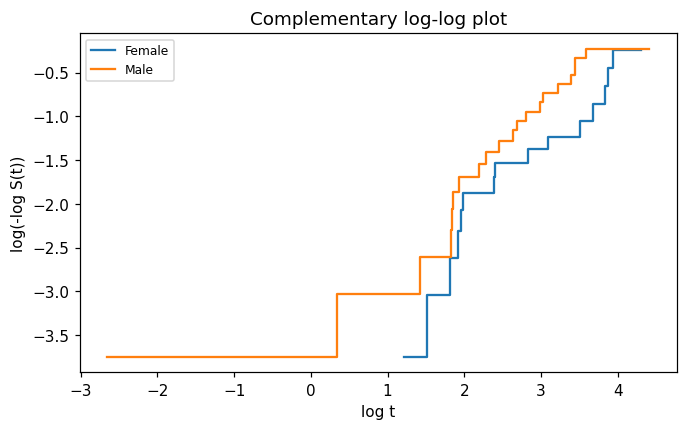

In [17]:
# Complementary log-log plot: parallel curves are what proportional hazards predicts.
fig, ax = plt.subplots(figsize=(7, 4))
for sex, colour in [('Female', 'C0'), ('Male', 'C1')]:
    m = BC['sex'] == sex
    sf = KaplanMeierFitter().fit(BC.loc[m, 'time'],
                                 BC.loc[m, 'status']).survival_function_.iloc[:, 0]
    keep = (sf > 0) & (sf < 1) & (sf.index > 0)
    ax.step(np.log(sf.index[keep]), np.log(-np.log(sf[keep].values)),
            where='post', color=colour, label=sex)
ax.set(xlabel='log t', ylabel='log(-log S(t))', title='Complementary log-log plot')
ax.legend(fontsize=8)
plt.show()

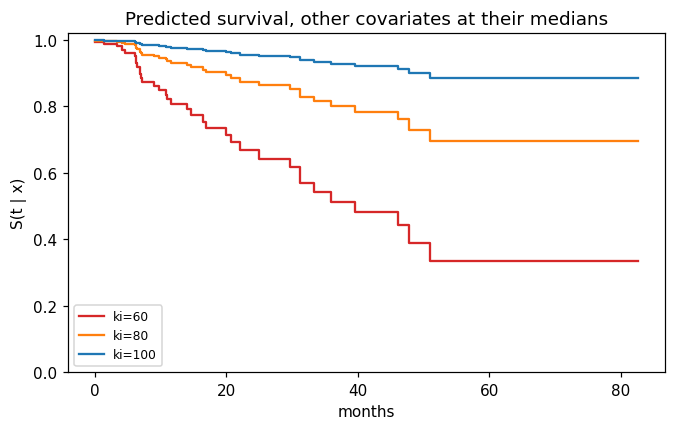

S(36 | ki=60, 80, 100) = [0.514 0.801 0.929]
median survival        = [39.54   inf   inf]


In [18]:
# From coefficients to curves: S(t | x) = S0(t) ** exp(x'beta), Breslow baseline.
med = X.drop(columns=['time', 'status']).median().to_frame().T   # median covariate profile
prof = pd.concat([med] * 3, ignore_index=True)
prof['ki'] = [60., 80., 100.]                                    # vary one covariate only

sf = cph.predict_survival_function(prof)
fig, ax = plt.subplots(figsize=(7, 4))
for j, (colour, lab) in enumerate(zip(['C3', 'C1', 'C0'], ['ki=60', 'ki=80', 'ki=100'])):
    ax.step(sf.index, sf.iloc[:, j], where='post', color=colour, label=lab)
ax.set(xlabel='months', ylabel='S(t | x)', ylim=(0, 1.02),
       title='Predicted survival, other covariates at their medians')
ax.legend(fontsize=8)
plt.show()

idx = sf.index[sf.index <= 36][-1]
print('S(36 | ki=60, 80, 100) =', np.round(sf.loc[idx].values, 3))
print('median survival        =', np.round(cph.predict_median(prof).values, 2))

**Reading the output.** Every Schoenfeld $p$-value exceeds 0.39, so there is no evidence against proportional hazards — with 35 events that is weak reassurance rather than a clean bill of health, and "failing to reject" is not "accepting". The complementary log-log curves for men and women stay roughly parallel, which is the same conclusion by eye.

Turning the fit into curves: at 36 months, with the other covariates at their medians, $\hat S=0.514$ for $ki=60$ against $0.801$ at $ki=80$ and $0.929$ at $ki=100$. The median is 39.5 months at $ki=60$ and is never reached above that within the 82.56 months of follow-up (`inf` in the printout). These are the numbers a clinician can act on; the hazard ratio is the mechanism behind them.

## Lecture exercises — worked Python solutions

These are the exercises from the lecture slides, solved step by step: the `[Python]`-tagged ones get runnable code reproducing the slide numbers, and the conceptual and mathematical ones get a concise answer with a numerical check. Run each cell and compare with the slide solutions. Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and on Colab.

### Exercise 11.1 — Why the shortcuts fail [Concept]

**Task (from the slides).** A streaming service has 10 000 subscribers; 1 200 cancelled last year and the rest are still subscribed. (1) An analyst averages the tenure of the 1 200 cancellers — which way is that biased? (2) A colleague averages current tenure over all 10 000 — which way is *that* biased? (3) What does a still-subscribed customer contribute? (4) Why is a "cancelled within 12 months?" classifier a poor substitute?

**Answer.**

1. **Biased downwards.** To have cancelled inside a one-year window you must have had a short subscription, so long-lived customers are systematically excluded. This is shortcut (a) of §2, which gave a median of 11.6 instead of 47.8 months on `BrainCancer`.
2. **Also biased downwards.** For an active customer, current tenure is a *lower bound* on the eventual subscription length, and averaging lower bounds as if they were exact understates the mean — shortcut (b).
3. That $T_i > Y_i$. An active customer of 30 months' tenure belongs in the **risk set** at every time up to month 30; Kaplan–Meier and Cox both use exactly this, by shrinking the denominator $r_k$ rather than deleting the row.
4. Anyone who joined less than 12 months ago has no label at all, so the newest cohorts are silently dropped — and the target changes meaning every time the snapshot date moves.

### Exercise 11.2 — Reading $(Y,\delta)$ off a study [Math]

**Task (from the slides).** A study runs for 36 months. A enrols at month 0 and has the event at 18; B enrols at 0 and is event-free at closure; C enrols at month 12 and moves abroad 9 months later; D enrols at month 24 and has the event 4 months later. Give $(Y_i,\delta_i)$, classify the censoring, list $R(10)$, and say why $\sum_i Y_i/4$ is not an estimate of $E[T]$.

**Answer.**

| Subject | $C_i$ | $Y_i=\min(T_i,C_i)$ | $\delta_i$ | reason |
|---|---|---|---|---|
| A | 36 | 18 | 1 | event seen at 18 |
| B | 36 | 36 | 0 | still event-free at closure |
| C | 9 | 9 | 0 | lost to follow-up at 9 |
| D | 12 | 4 | 1 | event seen at 4 |

B is **administrative** censoring — the calendar ran out, which cannot depend on B's risk. C is **loss to follow-up**, so independence is an argument rather than a fact and must be stated out loud. The risk set is $R(10)=\{i: Y_i\ge 10\}=\{A,B\}$: C left at 9, and D's event occurred at 4 (the clock is time since *enrolment*, not calendar time). Finally, $\tfrac14(18+36+9+4)=16.75$ mixes two exact times with two lower bounds — it estimates a feature of the *study design*, and enrolling B a year earlier would change it although nothing about the disease did.

### Exercise 11.3 — Kaplan–Meier by hand [Math]

**Task (from the slides).** Six patients: $4,\;6^{+},\;8,\;11^{+},\;12,\;15$. Tabulate $t_k,r_k,d_k$, compute $\hat S$ at each event time, give $\hat S(10)$ and the median, then redo it treating the two censored patients as deaths.

**Answer.** Event times are 4, 8, 12, 15 with $r_k = 6, 4, 2, 1$ and $d_k=1$ throughout, so $\hat S = 0.8333,\ 0.6250,\ 0.3125,\ 0$. At $t_2=8$ the risk set is $\{8,11^{+},12,15\}$, hence $r_2=4$: the patient censored at 6 has left, but was counted at $t_1$. $\hat S$ is flat between event times, so $\hat S(10)=\hat S(8)=0.625$, and the median — the first $t$ with $\hat S(t)\le 0.5$ — is **12**. Treating the censorings as deaths gives the plain empirical curve $5/6, 4/6, 3/6, \ldots$ and drags the median down to 11.

In [19]:
km_ex = KaplanMeierFitter().fit([4, 6, 8, 11, 12, 15], [1, 0, 1, 0, 1, 1])
print(km_ex.survival_function_.round(4).to_string())
print('S(10) =', km_ex.survival_function_at_times(10).iloc[0],
      ' median =', km_ex.median_survival_time_)

km_bad = KaplanMeierFitter().fit([4, 6, 8, 11, 12, 15], [1, 1, 1, 1, 1, 1])
print('censoring treated as death -> median =', km_bad.median_survival_time_)

          KM_estimate
timeline             
0.0            1.0000
4.0            0.8333
6.0            0.8333
8.0            0.6250
11.0           0.6250
12.0           0.3125
15.0           0.0000
S(10) = 0.625  median = 12.0
censoring treated as death -> median = 11.0


### Exercise 11.4 — The log-rank test by hand [Math]

**Task (from the slides).** Arm A: $6,\;7^{+},\;10,\;15^{+}$; arm B: $3,\;5,\;9,\;12^{+}$. Build the tables, compute $O_A$ and $E_A$, and with $V_A=1.1893$ give the statistic and the conclusion.

**Answer.** The death times are 3, 5, 6, 9, 10 (censorings contribute no table; they only shrink later risk sets):

| $t_k$ | $r_{Ak}$ | $r_{Bk}$ | $r_k$ | $d_k$ | $d_{Ak}$ | $E_{Ak}=d_k r_{Ak}/r_k$ |
|---|---|---|---|---|---|---|
| 3 | 4 | 4 | 8 | 1 | 0 | 0.5000 |
| 5 | 4 | 3 | 7 | 1 | 0 | 0.5714 |
| 6 | 4 | 2 | 6 | 1 | 1 | 0.6667 |
| 9 | 2 | 2 | 4 | 1 | 0 | 0.5000 |
| 10 | 2 | 1 | 3 | 1 | 1 | 0.6667 |

$O_A = 2$ and $E_A = 2.9048$, so $Z=(2-2.9048)/\sqrt{1.1893}=-0.830$, $Z^2=0.688 < 3.84$ and $p=0.407$. **No evidence of a difference**: arm A had fewer deaths than expected, but with five events the standard error swamps the gap.

In [20]:
r = logrank_test([6, 7, 10, 15], [3, 5, 9, 12], [1, 0, 1, 0], [1, 1, 1, 0])
print('chi2 = %.4f   p = %.4f' % (r.test_statistic, r.p_value))

chi2 = 0.6883   p = 0.4068


### Exercise 11.5 — Hazard-ratio arithmetic [Math]

**Task (from the slides).** A Cox model for time to churn gives $\hat\beta_{\text{price}}=0.024$ (se 0.006) per euro and $\hat\beta_{\text{onboarded}}=-0.693$ (se 0.210). Give the hazard ratio for a 10-euro increase; the hazard ratio for onboarding and its interpretation; a test and 95% interval for onboarding; and the hazard ratio between two customers differing by 20 euros where the cheaper one onboarded.

In [21]:
from scipy import stats

b_price, se_price = 0.024, 0.006
b_onb,   se_onb   = -0.693, 0.210

print('(1) HR per 10 euros   : %.3f' % np.exp(10 * b_price))
print('(2) HR for onboarding : %.3f' % np.exp(b_onb))
z = b_onb / se_onb
print('(3) z = %.2f, p = %.4f, 95%% CI on HR = [%.3f, %.3f]'
      % (z, 2 * stats.norm.cdf(-abs(z)),
         np.exp(b_onb - 1.96 * se_onb), np.exp(b_onb + 1.96 * se_onb)))
print('(4) combined HR       : %.2f' % np.exp(20 * b_price - b_onb))   # log HRs add

(1) HR per 10 euros   : 1.271
(2) HR for onboarding : 0.500
(3) z = -3.30, p = 0.0010, 95% CI on HR = [0.331, 0.755]
(4) combined HR       : 3.23


**Reading the output.** A 10-euro increase multiplies the churn rate by $e^{0.24}=1.271$; onboarding halves it ($e^{-0.693}=0.500$), at every tenure. The test gives $z=-3.30$, $p\approx0.001$, and the interval is built on the $\beta$ scale and *then* exponentiated, which is why $[0.331,0.755]$ is asymmetric around 0.500. Hazards multiply, so log hazards add: the expensive, non-onboarded customer faces $e^{0.48+0.693}=e^{1.173}=3.23$ times the churn rate. Never average hazard ratios, and never add standard errors on the ratio scale.

### Exercise 11.6 — Diagnosing and fixing a PH violation [Concept]

**Task (from the slides).** For `annual_contract` the Schoenfeld test gives $p=0.002$ and the complementary log-log curves cross at about month 14, yet the estimated hazard ratio is 0.98 with $p=0.81$. Explain the story, why the null result is an artefact, two fixes, and what single number to put in front of a board.

**Answer.**

1. **The story.** Annual contracts lock customers in, so their hazard is very low early and spikes at renewal, while monthly customers churn at a steady moderate rate. Before month 14 the annual contract is protective; afterwards it is dangerous. The crossing is not a nuisance — it *is* the finding.
2. **Why $\widehat{HR}=0.98$ is an artefact.** A single $\beta$ forces one constant hazard ratio, and the fit lands near the time-average of a protective-then-harmful effect, so the early and late excesses cancel. This is the same cancellation that makes the log-rank test blind to crossing curves; the model was asked the wrong question and answered it faithfully.
3. **Two fixes.** *Split the follow-up* at month 14 and fit a hazard ratio in each period — but the split point is a choice, and choosing it from these data invalidates the naive $p$-values. Or *stratify* on `annual_contract`, which keeps every other coefficient interpretable at the cost of getting no hazard ratio for contract type at all.
4. **The board number.** Not a hazard ratio. Report retention at a decision-relevant horizon — $\hat S(12)$ and $\hat S(24)$ by contract type, with intervals — or $\mathrm{RMST}(24)$. Both are well defined when hazards cross.

### Extended Exercise 11.1 — Kaplan–Meier in Python [Python]

**Task (from the slides).**
1. Fit the overall Kaplan–Meier curve; report $\hat S(20)$ with its 95% interval and the median.
2. Fit separate curves for men and women; report each group's size, deaths and median.
3. Plot both curves with censoring marks and say what the plot suggests.
4. Verify by direct arithmetic that the first three steps are 0.9886, 0.9771, 0.9654.

In [22]:
# (1) the overall curve ------------------------------------------------------
BC = load('BrainCancer', index_col=0)
km = KaplanMeierFitter().fit(BC['time'], BC['status'])
print('S(20) = %.4f' % km.survival_function_at_times(20).iloc[0])
print('95% CI  ', np.round(km.confidence_interval_.loc[:20].iloc[-1].values, 4))
print('median  ', km.median_survival_time_)

# (2) by sex -----------------------------------------------------------------
for s in ['Female', 'Male']:
    m = BC['sex'] == s
    k = KaplanMeierFitter().fit(BC.loc[m, 'time'], BC.loc[m, 'status'])
    print('%-6s n=%d deaths=%d median=%.2f'
          % (s, m.sum(), BC.loc[m, 'status'].sum(), k.median_survival_time_))

S(20) = 0.7132
95% CI   [0.5996 0.7998]
median   47.8
Female n=45 deaths=15 median=51.02
Male   n=43 deaths=20 median=31.25


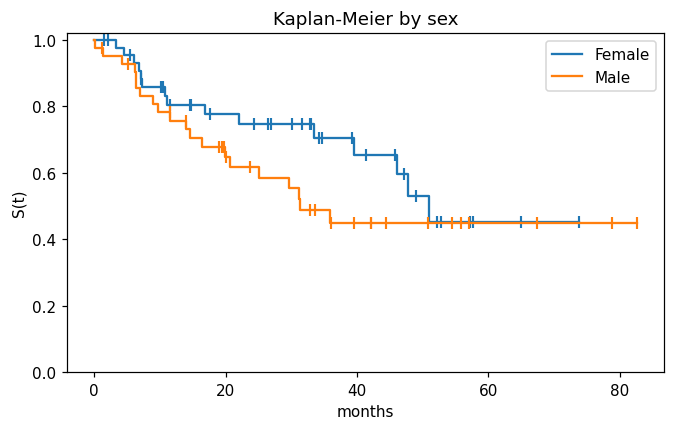

          at_risk  observed  censored
event_at                             
0.00           88         0         0
0.07           88         1         0
1.18           87         0         1
1.41           86         1         0
1.54           85         0         1
2.03           84         0         1
3.38           83         1         0
by hand: [0.9886 0.9771 0.9654]


In [23]:
# (3) both curves with censoring marks ---------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for s, colour in [('Female', 'C0'), ('Male', 'C1')]:
    m = BC['sex'] == s
    k = KaplanMeierFitter().fit(BC.loc[m, 'time'], BC.loc[m, 'status'], label=s)
    k.plot_survival_function(ax=ax, ci_show=False, color=colour)
    c = BC.loc[m & (BC['status'] == 0), 'time']
    ax.plot(c, k.survival_function_at_times(c).values, '|', color=colour, ms=8, mew=1.4)
ax.set(xlabel='months', ylabel='S(t)', ylim=(0, 1.02), title='Kaplan-Meier by sex')
plt.show()

# (4) the first three steps, from the at-risk table ---------------------------
print(km.event_table.head(7)[['at_risk', 'observed', 'censored']])
print('by hand:', np.round([87 / 88, 87 / 88 * 85 / 86, 87 / 88 * 85 / 86 * 82 / 83], 4))

**Reading the output.** (1) 71.3% of patients are alive at 20 months, but the interval $[0.600,0.800]$ is already 20 percentage points wide with 88 patients — survival curves are data-hungry. (2)–(3) The male median is 31.25 months against 51.02 for women and the male curve sits below the female curve almost everywhere, so the plot *suggests* worse male survival; with 35 deaths in total that is not much evidence, which is exactly what the log-rank test says. (4) `event_table` gives $r_k=88,86,83$ and $d_k=1,1,1$ at $t_k=0.07,1.41,3.38$, and the running product $\tfrac{87}{88}\cdot\tfrac{85}{86}\cdot\tfrac{82}{83}$ reproduces 0.9886, 0.9771, 0.9654. Note $r_2=86$ rather than 87: the censoring at 1.18 removed a subject before the second death.

### Extended Exercise 11.2 — The Cox model in Python [Python]

**Task (from the slides).**
1. Fit a Cox model with all six covariates, coding `diagnosis` against **Meningioma**; report $\hat\beta$, $e^{\hat\beta}$ and $p$ for `ki` and for HG glioma.
2. Convert the `ki` coefficient into a hazard ratio for a ten-point increase and write the interpretation.
3. Report the concordance index and the overall likelihood-ratio test.
4. Test proportional hazards with Schoenfeld residuals.
5. Predict and plot $\hat S(t\mid x)$ for $ki\in\{60,80,100\}$ with the other covariates at their medians.

In [24]:
# (1) fit --------------------------------------------------------------------
BCc = load('BrainCancer', index_col=0).dropna()                  # 87 complete cases
BCc['diagnosis'] = pd.Categorical(BCc['diagnosis'],              # Meningioma = reference
        categories=['Meningioma', 'HG glioma', 'LG glioma', 'Other'])
X = pd.get_dummies(BCc, drop_first=True).astype(float)
cph = CoxPHFitter().fit(X, duration_col='time', event_col='status')
print(cph.summary.loc[['ki', 'diagnosis_HG glioma'],
                      ['coef', 'exp(coef)', 'p']].round(4))

# (2)-(3) rescaled hazard ratio, discrimination, global test -------------------
print('\nHR per 10 ki points : %.3f' % np.exp(10 * cph.params_['ki']))
print('C-index             : %.4f' % cph.concordance_index_)
lr = cph.log_likelihood_ratio_test()
print('LR test             : chi2 = %.2f on %d df, p = %.2g'
      % (lr.test_statistic, lr.degrees_freedom, lr.p_value))

                       coef  exp(coef)       p
covariate                                     
ki                  -0.0550     0.9465  0.0027
diagnosis_HG glioma  2.1546     8.6241  0.0000

HR per 10 ki points : 0.577
C-index             : 0.7943
LR test             : chi2 = 41.37 on 8 df, p = 1.8e-06


diagnosis_HG glioma    0.825
diagnosis_LG glioma    0.735
diagnosis_Other        0.453
gtv                    0.483
ki                     0.820
loc_Supratentorial     0.625
sex_Male               0.397
stereo_SRT             0.452
range of p-values: 0.40 to 0.82


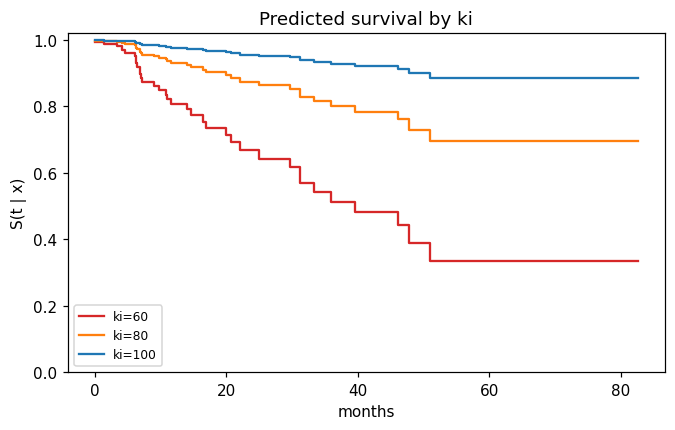

S(36 | ki=60,80,100) = [0.514 0.801 0.929]
median               = [39.54   inf   inf]


In [25]:
# (4) proportional hazards ----------------------------------------------------
ph = proportional_hazard_test(cph, X, time_transform='rank')
print(ph.summary['p'].round(3).to_string())
print('range of p-values: %.2f to %.2f' % (ph.summary['p'].min(), ph.summary['p'].max()))

# (5) predicted survival curves -----------------------------------------------
med = X.drop(columns=['time', 'status']).median().to_frame().T
prof = pd.concat([med] * 3, ignore_index=True)
prof['ki'] = [60., 80., 100.]
sf = cph.predict_survival_function(prof)

fig, ax = plt.subplots(figsize=(7, 4))
for j, (colour, lab) in enumerate(zip(['C3', 'C1', 'C0'], ['ki=60', 'ki=80', 'ki=100'])):
    ax.step(sf.index, sf.iloc[:, j], where='post', color=colour, label=lab)
ax.set(xlabel='months', ylabel='S(t | x)', ylim=(0, 1.02), title='Predicted survival by ki')
ax.legend(fontsize=8)
plt.show()

idx = sf.index[sf.index <= 36][-1]
print('S(36 | ki=60,80,100) =', np.round(sf.loc[idx].values, 3))
print('median               =', np.round(cph.predict_median(prof).values, 2))

**Reading the output.** (1) `ki`: $\hat\beta=-0.0550$, $e^{\hat\beta}=0.947$, $p=0.003$; HG glioma: $\hat\beta=2.1546$, $e^{\hat\beta}=8.624$, $p<0.001$. The other six covariates all have $p>0.12$. (2) $e^{10\times(-0.0550)}=0.577$: *holding tumour type, volume, site, sex and technique fixed, ten more Karnofsky points are associated with a 42% lower death rate at every follow-up time*. (3) $C=0.794$, and the likelihood-ratio test is $\chi^2_8=41.4$, $p=1.8\times10^{-6}$ — the covariate block clearly carries signal even though most single coefficients do not. (4) Schoenfeld $p$-values run from 0.40 to 0.82: no evidence against proportional hazards, which with 35 events is weak reassurance. (5) $\hat S(36)=0.514,\,0.801,\,0.929$ for $ki=60,80,100$; the median is 39.5 months at $ki=60$ and not reached above that.

A trap worth naming: if you let `get_dummies` pick the reference level alphabetically it chooses *HG glioma*, and every `diagnosis` coefficient changes sign and meaning while the fit stays numerically identical.

### Extended Exercise 11.3 — Publication bias, measured [Integrative]

**Task (from the slides).** `Publication` records the time in months from completion to publication for 244 NHLBI-funded trials; `status = 1` means published and `posres = 1` means a statistically significant primary result. (1) Run the log-rank test by `posres` — what does it appear to say? (2) Fit a Cox model with `posres` alone, then add `impact`, `clinend`, `multi`, `sampsize` and `budget`. (3) Which covariate does the work? (4) State the conclusion for a journal editor.

(244, 9) | published: 156 | positive results: 98
(1) log-rank by posres: chi2 = 0.8440, p = 0.3583
   negative / null  n=146 published= 87 median=25.10
   positive         n= 98 published= 69 median=23.13


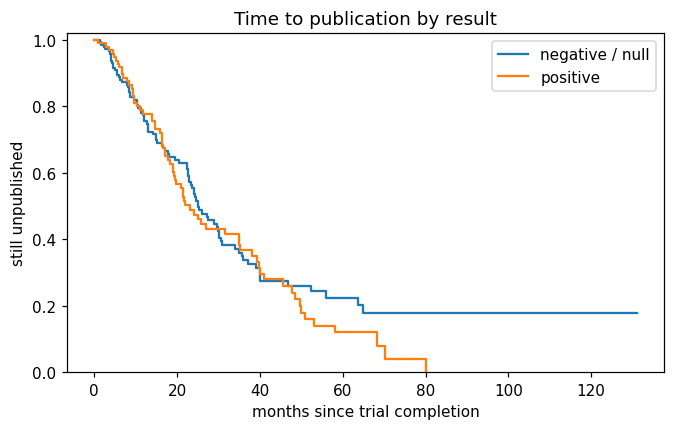

In [26]:
PUB = load('Publication', index_col=0)
print(PUB.shape, '| published:', int(PUB['status'].sum()),
      '| positive results:', int(PUB['posres'].sum()))

pos = PUB['posres'] == 1
r = logrank_test(PUB.loc[pos, 'time'],   PUB.loc[~pos, 'time'],
                 PUB.loc[pos, 'status'], PUB.loc[~pos, 'status'])
print('(1) log-rank by posres: chi2 = %.4f, p = %.4f' % (r.test_statistic, r.p_value))

fig, ax = plt.subplots(figsize=(7, 4))
for mask, colour, lab in [(~pos, 'C0', 'negative / null'), (pos, 'C1', 'positive')]:
    k = KaplanMeierFitter().fit(PUB.loc[mask, 'time'], PUB.loc[mask, 'status'], label=lab)
    k.plot_survival_function(ax=ax, ci_show=False, color=colour)
    print('   %-16s n=%3d published=%3d median=%.2f'
          % (lab, mask.sum(), PUB.loc[mask, 'status'].sum(), k.median_survival_time_))
ax.set(xlabel='months since trial completion', ylabel='still unpublished',
       ylim=(0, 1.02), title='Time to publication by result')
plt.show()

In [27]:
# (2) unadjusted, then adjusted ----------------------------------------------
c1 = CoxPHFitter().fit(PUB[['time', 'status', 'posres']], 'time', 'status')
print('posres alone : HR = %.3f, p = %.4f'
      % (c1.summary.loc['posres', 'exp(coef)'], c1.summary.loc['posres', 'p']))

design = PUB.drop(columns=['mech'])          # 'mech' is the funding mechanism (a factor)
c2 = CoxPHFitter().fit(design, 'time', 'status')
print()
print(c2.summary[['coef', 'exp(coef)', 'z', 'p']].round(4))

posres alone : HR = 1.160, p = 0.3596


             coef  exp(coef)       z       p
covariate                                   
posres     0.5708     1.7696  3.2438  0.0012
multi     -0.0409     0.9600 -0.1627  0.8708
clinend    0.5462     1.7267  2.0847  0.0371
sampsize   0.0000     1.0000  0.3177  0.7507
budget     0.0044     1.0044  1.7795  0.0752
impact     0.0583     1.0601  8.7355  0.0000


**Reading the output.** (1) Taken alone, $\chi^2_1=0.84$, $p=0.358$: trials with and without a positive result appear to be published at indistinguishable rates, and the two curves nearly overlie each other (medians 23.1 against 25.1 months). (2) Adding the journal-level covariates moves `posres` from $\widehat{HR}=1.16$, $p=0.360$ to $\widehat{HR}=1.77$, $p=0.001$ — the log-rank test is *marginal* and cannot hold anything fixed, and here the confounding runs opposite to the effect of interest, masking it. (3) The work is done by `impact`, the journal impact factor: $\hat\beta=0.0583$, $\widehat{HR}=1.060$ per point, $z=8.7$. High-impact journals are slow and positive trials aim at them, so a positive result buys a faster decision but a slower venue, and the two effects cancel in the raw comparison. `clinend` also matters ($\widehat{HR}=1.73$, $p=0.037$); `multi`, `sampsize` and `budget` do not.

(4) *"Among comparable trials — same target journal impact, same endpoint type, same size and budget — those with a positive primary result were published at 1.8 times the rate of those without ($p=0.001$), so the raw publication times understate publication bias rather than refuting it."* The transferable lesson: when a log-rank test and a Cox model disagree, it is the covariates that are telling you something.

### Exercise 11.7 — The exponential model [Math] (appendix)

**Task (from the slides).** With a constant hazard $h(t)=\lambda$: derive $H(t)$ and $S(t)$, find the median, show the family satisfies proportional hazards, and evaluate $\hat\lambda=D/\sum_i Y_i$ on `BrainCancer`.

**Answer.** $H(t)=\lambda t$ and $S(t)=e^{-\lambda t}$ — the exponential distribution, the unique memoryless survival law — so the median is $\log 2/\lambda$. With $\lambda_i=\lambda_0 e^{x_i^{\top}\beta}$ the hazard is $h_0(t)e^{x_i^{\top}\beta}$ with the *constant* baseline $h_0(t)\equiv\lambda_0$, and the ratio of two subjects' hazards is free of $t$: an exponential model is a Cox model with the baseline pinned down. The estimator's denominator must be **total time at risk**, which is what censored subjects contribute — not $n$, and not the event times alone.

In [28]:
D, total_time = BC['status'].sum(), BC['time'].sum()
lam = D / total_time
print('D = %d events, total follow-up = %.2f months' % (D, total_time))
print('lambda_hat = %.6f per month -> implied median = %.2f months'
      % (lam, np.log(2) / lam))
print('Kaplan-Meier median               = %.2f months' % km.median_survival_time_)

D = 35 events, total follow-up = 2416.26 months
lambda_hat = 0.014485 per month -> implied median = 47.85 months
Kaplan-Meier median               = 47.80 months


**Reading the output.** $\hat\lambda = 35/2416.26 = 0.014485$ deaths per month of follow-up, so the implied median is $\log 2/\hat\lambda = 47.85$ months — strikingly close to the Kaplan–Meier value of 47.8. That agreement is reassuring but partly luck: the exponential model buys it by assuming a constant hazard over nearly seven years, and the two estimates diverge at other quantiles.

## 7. Exercises

1. Cross-validate the C-index (`lifelines.utils.k_fold_cross_validation` with `scoring_method='concordance_index'`). How much of the in-sample 0.794 survives?
2. Add an interaction between `ki` and `diagnosis` to the Cox fit and test it with a likelihood-ratio test against the model without it.
3. Fit `lifelines.WeibullAFTFitter` to the same data. Compare its predicted median survival at $ki=60,80,100$ with the Cox predictions above, and say which assumption each model buys its answer with.
4. Repeat the analysis on `Publication`, this time keeping the `mech` factor as dummies. Does the estimated effect of `posres` change, and does the proportional-hazards assumption survive?